In [ ]:
#import and load data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

df.head()

,name,year-month,avg_monthly_pct_change
0,AAPL,2025-12,0.025133
1,AAPL,2026-01,-0.215004
2,AAPL,2026-02,-0.005960
3,AAPL,2026-03,-0.141364
4,AAPL,2026-04,0.285616


In [ ]:
#clean column names
df.columns = ["name", "year_month", "avg_monthly_pct_change"]

df["year_month"] = df["year_month"].astype(str)

df.head()

,name,year_month,avg_monthly_pct_change
0,AAPL,2025-12,0.025133
1,AAPL,2026-01,-0.215004
2,AAPL,2026-02,-0.005960
3,AAPL,2026-03,-0.141364
4,AAPL,2026-04,0.285616


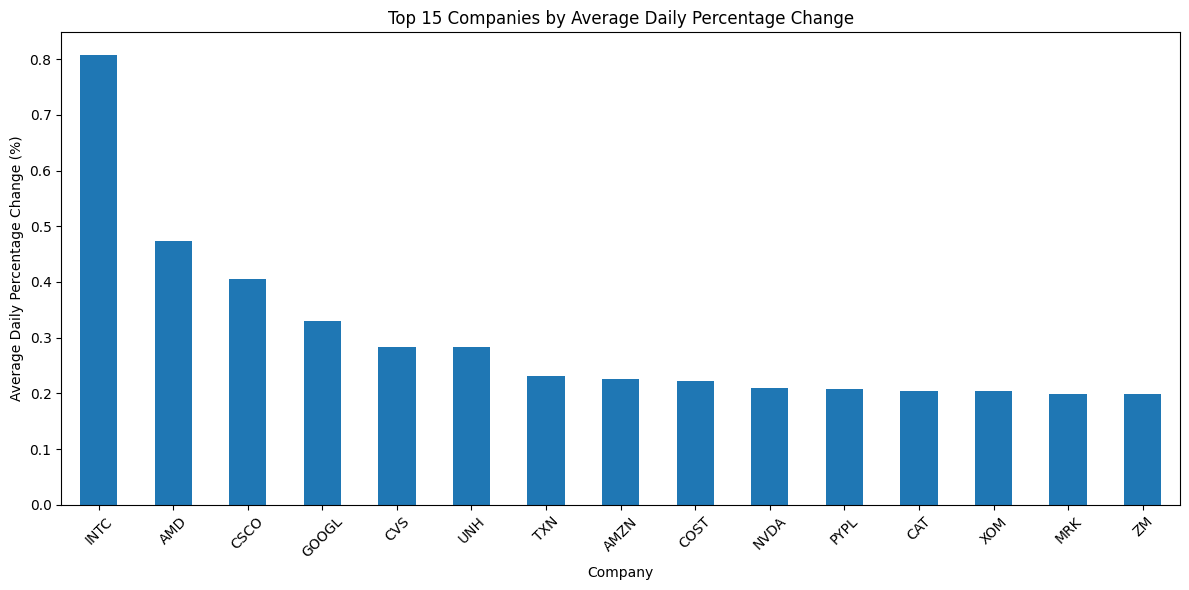

In [ ]:
#Visualization 1: Ranking Companies by Average Daily Percentage Change
company_avg = (
    df.groupby("name")["avg_monthly_pct_change"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
company_avg.plot(kind="bar")

plt.title("Top 15 Companies by Average Daily Percentage Change")
plt.xlabel("Company")
plt.ylabel("Average Daily Percentage Change (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows which companies had the highest average percentage change between opening and closing stock prices. Instead of showing all 66 companies, I displayed the top 15 to keep the visualization readable while still highlighting the strongest performers.

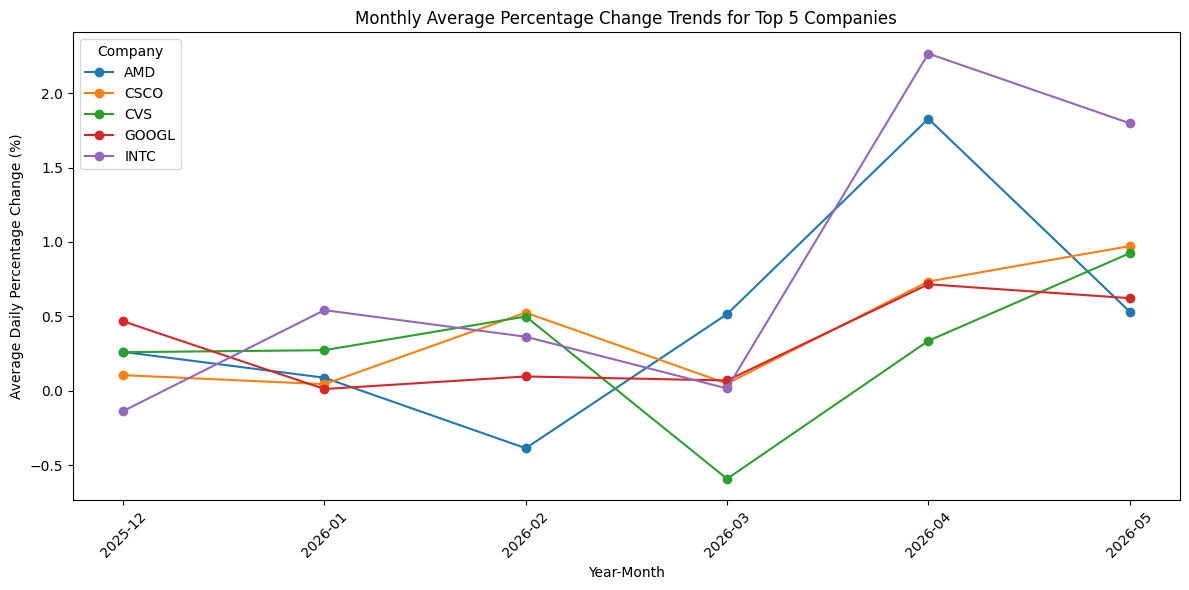

In [ ]:
# Visualization 2: Monthly Average Percentage Change Trends
top_5_companies = (
    df.groupby("name")["avg_monthly_pct_change"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

trend_df = df[df["name"].isin(top_5_companies)]

pivot_df = trend_df.pivot(
    index="year_month",
    columns="name",
    values="avg_monthly_pct_change"
)

plt.figure(figsize=(12, 6))

for company in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[company], marker="o", label=company)

plt.title("Monthly Average Percentage Change Trends for Top 5 Companies")
plt.xlabel("Year-Month")
plt.ylabel("Average Daily Percentage Change (%)")
plt.xticks(rotation=45)
plt.legend(title="Company")
plt.tight_layout()
plt.show()

The line chart shows how the monthly average percentage change changed over time for the top 5 companies. This helps show whether the companies'performances was consistent across months or if there were noticeable changes in certain periods.